In [4]:
"""
Minimal SAM training loop for an MLP
------------------------------------
* Single–hidden-layer MLP (feel free to change depth/width)
* SAM wrapper implemented in < 60 lines
* CIFAR-10 loader as a quick sanity-check (swap in your own DataLoader if you like)
"""

import torch
from torch import nn
from torch.utils.data import DataLoader
import torchvision, torchvision.transforms as T
import pandas as pd
import numpy as np
import sys
import os

project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.append(project_root)
from train_mlp import get_cifar_toy, muMLPTab9

os.environ["CUDA_VISIBLE_DEVICES"] = "3"

class MLP(nn.Module):
    def __init__(self, in_dim=3 * 32 * 32, hidden=1024, num_classes=10):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(hidden, num_classes, bias=False),
        )

    def forward(self, x):
        return self.net(x.flatten(1))


class SAM(torch.optim.Optimizer):
    r"""Implements Sharpness-Aware Minimisation (Foret et al., 2021).

       Usage:
           base = torch.optim.SGD
           optimizer = SAM(model.parameters(), base, lr=0.1, momentum=0.9, rho=0.05)
    """

    def __init__(self, params, base_optimizer, rho=0.05, **base_kwargs):
        if not isinstance(base_optimizer, torch.optim.Optimizer):
            self.base_optimizer = base_optimizer(params, **base_kwargs)
        else:  # already instantiated
            self.base_optimizer = base_optimizer
        defaults = dict(rho=rho, **self.base_optimizer.defaults)
        super().__init__(self.base_optimizer.param_groups, defaults)
        self.rho = rho

    @torch.no_grad()
    def first_step(self, zero_grad=False):
        # ‖g‖₂
        grad_norm = torch.norm(
            torch.stack(
                [
                    p.grad.norm(p=2)
                    for group in self.param_groups
                    for p in group["params"]
                    if p.grad is not None
                ]
            )
        )
        scale = self.rho / (grad_norm + 1e-12)

        for group in self.param_groups:
            for p in group["params"]:
                if p.grad is None:
                    continue
                e_w = p.grad * scale.to(p)              # ascent direction
                self.state[p]["e_w"] = e_w
                p.add_(e_w)                              # w ← w + ε
        if zero_grad:
            self.zero_grad()

    @torch.no_grad()
    def second_step(self, zero_grad=False):
        for group in self.param_groups:
            for p in group["params"]:
                if p.grad is None:
                    continue
                p.sub_(self.state[p]["e_w"])            # w ← w − ε  (back to centre)
        self.base_optimizer.step()                      # plain optimiser step
        if zero_grad:
            self.zero_grad()

    def step(self, *args, **kwargs):
        raise RuntimeError("Call first_step and second_step instead")

    def zero_grad(self):
        self.base_optimizer.zero_grad()


def train_epoch(model, loader, optimiser, loss_fn, device):
    model.train()
    losses_train, losses_adv, batch_sizes = [], [], []

    x, y = next(iter(loader))

    x, y = x.to(device), y.to(device)

    optimiser.zero_grad()
    loss_train = loss_fn(model(x), y)
    loss_train.backward()
    
    if isinstance(optimiser, SAM):
        optimiser.first_step(zero_grad=True)
        loss_adv = loss_fn(model(x), y)
        loss_adv.backward()
        optimiser.second_step(zero_grad=True)
        losses_adv.append(loss_adv.item())
    else:
        optimiser.step()
        losses_adv.append(None)
        
    losses_train.append(loss_train.item())
    batch_sizes.append(y.size(0))

    return losses_train, losses_adv, batch_sizes    

In [5]:
torch.manual_seed(0)
np.random.seed(0)

# ---------- Plain muP training loop ----------
epochs = 300
lr = 0.01
device = "cuda" if torch.cuda.is_available() else "cpu"
dl = get_cifar_toy(device=device)
# model = MLP(num_classes=1).to(device)
model = muMLPTab9(num_classes=1).to(device)
                             

optimiser = torch.optim.SGD(model.parameters(), lr=lr, momentum=0, weight_decay=0)
loss_fn = nn.MSELoss()

df_mup = pd.DataFrame(columns=["train", "adv", "batch_size"])
print("Epoch\tTrain\tAdv\tBatch Size")
for epoch in range(1, epochs + 1):
    losses_train, losses_adv, batch_sizes = train_epoch(model, dl, optimiser, loss_fn, device)
    df_mup.loc[epoch] = [losses_train[0], losses_adv[0], batch_sizes[0]]
    if epoch % 250 == 0:
        print(epoch)

# ---------- SAM (rho=0) training loop ----------
torch.manual_seed(0)
np.random.seed(0)

model = muMLPTab9(num_classes=1).to(device)
base_opt = torch.optim.SGD
optimiser = SAM(model.parameters(),
                base_opt,
                lr=lr, momentum=0, weight_decay=0,
                rho=0.00)      

df_mup_rho0 = pd.DataFrame(columns=["train", "adv", "batch_size"])
print("Epoch\tTrain\tAdv\tBatch Size")
for epoch in range(1, epochs + 1):
    losses_train, losses_adv, batch_sizes = train_epoch(model, dl, optimiser, loss_fn, device)
    df_mup_rho0.loc[epoch] = [losses_train[0], losses_adv[0], batch_sizes[0]]
    if epoch % 250 == 0:
        print(epoch)

# ---------- SAM (rho!=0) training loop ----------
torch.manual_seed(0)
np.random.seed(0)

model = muMLPTab9(num_classes=1).to(device)
base_opt = torch.optim.SGD
optimiser = SAM(model.parameters(),
                base_opt,
                lr=lr, momentum=0, weight_decay=0,
                rho=0.01)      

df_mup_rho = pd.DataFrame(columns=["train", "adv", "batch_size"])
print("Epoch\tTrain\tAdv\tBatch Size")
for epoch in range(1, epochs + 1):
    losses_train, losses_adv, batch_sizes = train_epoch(model, dl, optimiser, loss_fn, device)
    df_mup_rho.loc[epoch] = [losses_train[0], losses_adv[0], batch_sizes[0]]
    if epoch % 250 == 0:
        print(epoch)

Epoch	Train	Adv	Batch Size
250
Epoch	Train	Adv	Batch Size
250
Epoch	Train	Adv	Batch Size
250


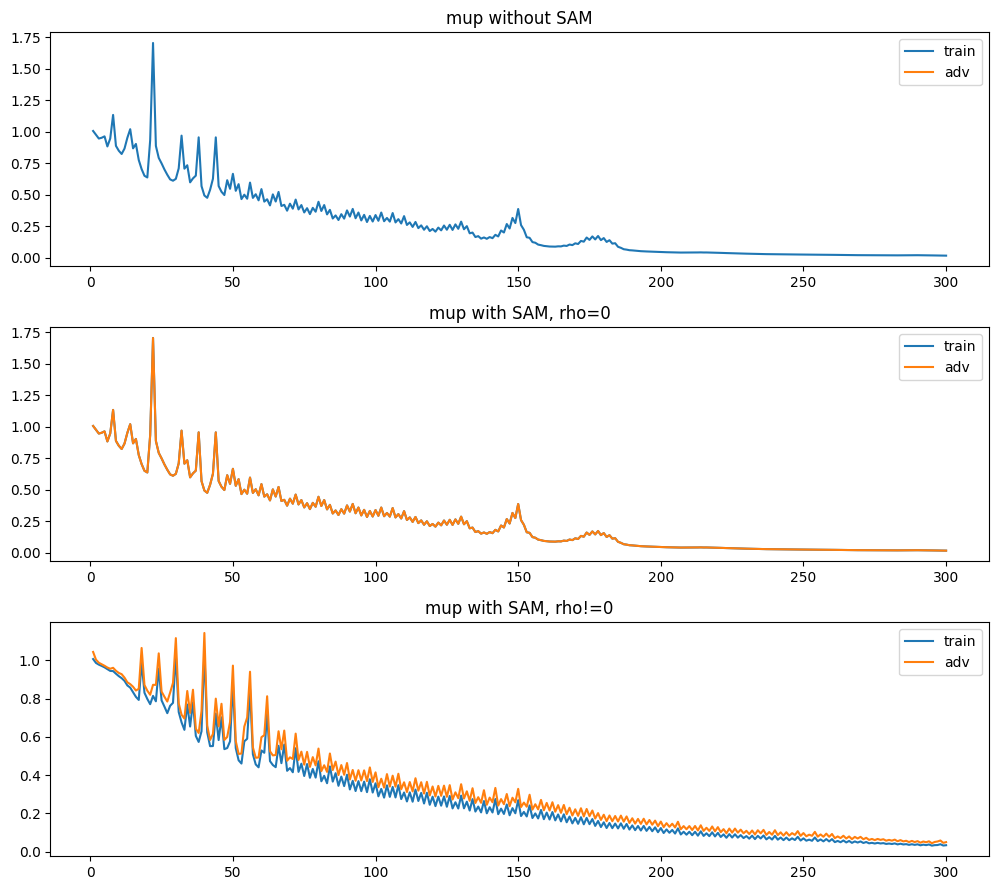

In [6]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(10, 9))

df_mup[["train", "adv"]].plot(ax=axes[0], title="mup without SAM")
df_mup_rho0[["train", "adv"]].plot(ax=axes[1], title="mup with SAM, rho=0")
df_mup_rho[["train", "adv"]].plot(ax=axes[2], title="mup with SAM, rho!=0")

plt.tight_layout()
plt.show()

In [12]:
def train_epoch(model, loader, optimiser, loss_fn, device):
    model.train()
    losses_train, losses_adv, batch_sizes = [], [], []

    x, y = next(iter(loader))

    x, y = x.to(device), y.to(device)

    optimiser.zero_grad()
    loss_train = loss_fn(model(x), y)
    loss_train.backward()
    
    if isinstance(optimiser, SAM):
        optimiser.first_step(zero_grad=True)
        loss_adv = loss_fn(model(x), y)
        loss_adv.backward()
        g_norm = torch.stack([p.grad.norm() for p in model.parameters()]).norm()
        optimiser.second_step(zero_grad=True)
        losses_adv.append(loss_adv.item())
    else:
        optimiser.step()
        losses_adv.append(None)
        g_norm = torch.stack([p.grad.norm() for p in model.parameters()]).norm()
    
    losses_train.append(loss_train.item())
    batch_sizes.append(y.size(0))

    return losses_train, losses_adv, batch_sizes, g_norm

## Hessian eval

In [29]:
from pyhessian import hessian

torch.manual_seed(0)
np.random.seed(0)

# ---------- Plain muP training loop ----------
epochs = 4000
lr = 0.01
device = "cuda" if torch.cuda.is_available() else "cpu"
dl = get_cifar_toy(device=device)
sharp_x, sharp_y = next(iter(dl))
# model = MLP(num_classes=1).to(device)
model = muMLPTab9(num_classes=1).to(device)
                             

optimiser = torch.optim.SGD(model.parameters(), lr=lr, momentum=0, weight_decay=0)
loss_fn = nn.MSELoss()

df_mup = pd.DataFrame(columns=["train", "adv", "batch_size", "eigen"])
print("Epoch\tTrain\tAdv\tBatch Size")
for epoch in range(1, epochs + 1):
    losses_train, losses_adv, batch_sizes, g_norm = train_epoch(model, dl, optimiser, loss_fn, device)
    df_mup.loc[epoch] = [losses_train[0], losses_adv[0], batch_sizes[0], None]
    if epoch % 100 == 0:
        hess = hessian(model, criterion=loss_fn, data=(sharp_x, sharp_y), cuda=True)
        top_eigenvalue = hess.eigenvalues(maxIter=400, top_n=1)[0][0]
        df_mup.loc[epoch, "eigen"] = top_eigenvalue
        print(epoch, losses_train[0], losses_adv[0], batch_sizes[0], top_eigenvalue)

Epoch	Train	Adv	Batch Size
100 0.33887102489719084 None 50 227.44380618585635
200 0.04553653698571943 None 50 158.499232610394
300 0.01660463704028528 None 50 174.1359297992339
400 0.008510411422001981 None 50 199.80536587186373
500 0.1090411297231701 None 50 231.6269672653051
600 0.021924634482044923 None 50 187.88128512961563
700 0.02342238575543323 None 50 218.7954325121758
800 1.872062470854262 None 50 63.61264707661248
900 0.01842844922015108 None 50 225.8689426050225
1000 0.0185662830863866 None 50 181.03391936830906
1100 0.00850175382674452 None 50 189.26760285450342
1200 0.007293920240042903 None 50 209.60575995314667
1300 0.006727833985748214 None 50 199.68478537990651
1400 0.0029572805307594837 None 50 200.69928726059945
1500 0.0022886236938436874 None 50 205.15288050799288
1600 0.001508387363673493 None 50 201.56148981775104
1700 0.0016190095204153473 None 50 200.9549794526778
1800 0.0012019946973713521 None 50 202.92828895870215
1900 0.0003420366300578533 None 50 203.826399

In [30]:
# ---------- SAM (rho=0) training loop ----------
torch.manual_seed(0)
np.random.seed(0)

rho = 0.0
model = muMLPTab9(num_classes=1).to(device)
base_opt = torch.optim.SGD
optimiser = SAM(model.parameters(),
                base_opt,
                lr=lr, momentum=0, weight_decay=0,
                rho=rho)      

df_mup_rho0 = pd.DataFrame(columns=["train", "adv", "batch_size", "eigen", "eos"])
print("Epoch\tTrain\tAdv\tBatch Size")
for epoch in range(1, epochs + 1):
    losses_train, losses_adv, batch_sizes, g_norm = train_epoch(model, dl, optimiser, loss_fn, device)
    df_mup_rho0.loc[epoch] = [losses_train[0], losses_adv[0], batch_sizes[0], None, None]
    if epoch % 100 == 0 or epoch == 1:
        hess = hessian(model, criterion=loss_fn, data=(sharp_x, sharp_y), cuda=True)
        top_eigenvalue = hess.eigenvalues(maxIter=400, top_n=1)[0][0]
        sam_edge = (g_norm / (2*0.000001)) * ( (1 + 8*0.000001/(lr*g_norm)).sqrt() - 1 )
        df_mup_rho0.loc[epoch, "eigen"] = top_eigenvalue
        df_mup_rho0.loc[epoch, "eos"] = sam_edge.item()
        print(epoch, top_eigenvalue, sam_edge)

# ---------- SAM (rho!=0) training loop ----------
torch.manual_seed(0)
np.random.seed(0)

rho = 0.01
model = muMLPTab9(num_classes=1).to(device)
base_opt = torch.optim.SGD
optimiser = SAM(model.parameters(),
                base_opt,
                lr=lr, momentum=0, weight_decay=0,
                rho=rho)      

df_mup_rho = pd.DataFrame(columns=["train", "adv", "batch_size", "eigen", "eos"])
print("Epoch\tTrain\tAdv\tBatch Size")
for epoch in range(1, epochs + 1):
    losses_train, losses_adv, batch_sizes, g_norm = train_epoch(model, dl, optimiser, loss_fn, device)
    df_mup_rho.loc[epoch] = [losses_train[0], losses_adv[0], batch_sizes[0], None, None]
    if epoch % 100 == 0 or epoch == 1:
        hess = hessian(model, criterion=loss_fn, data=(sharp_x, sharp_y), cuda=True)
        top_eigenvalue = hess.eigenvalues(maxIter=400, top_n=1)[0][0]
        sam_edge = (g_norm / (2*rho)) * ( (1 + 8*rho/(lr*g_norm)).sqrt() - 1 )
        df_mup_rho.loc[epoch, "eigen"] = top_eigenvalue
        df_mup_rho.loc[epoch, "eos"] = sam_edge.item()
        print(epoch, top_eigenvalue, sam_edge.item())

Epoch	Train	Adv	Batch Size
1 170.36365353653488 tensor(199.9910, device='cuda:0')
100 227.34726236098967 tensor(199.9944, device='cuda:0')
200 158.50392600257723 tensor(199.9325, device='cuda:0')
300 174.10924240512068 tensor(199.9309, device='cuda:0')
400 199.91979726715502 tensor(199.9194, device='cuda:0')
500 231.48262446614729 tensor(199.9818, device='cuda:0')
600 187.777469849007 tensor(199.9567, device='cuda:0')
700 218.8558119088453 tensor(199.9849, device='cuda:0')
800 63.60370199455223 tensor(199.9986, device='cuda:0')
900 225.84778504076996 tensor(199.9755, device='cuda:0')
1000 180.97936605564084 tensor(199.9075, device='cuda:0')
1100 189.25379806466128 tensor(199.9569, device='cuda:0')
1200 209.75036496114006 tensor(199.9681, device='cuda:0')
1300 199.5059615287794 tensor(199.9697, device='cuda:0')
1400 200.6778388500636 tensor(199.9484, device='cuda:0')
1500 205.17897552924273 tensor(199.9453, device='cuda:0')
1600 201.63378685149092 tensor(199.9340, device='cuda:0')
1700 

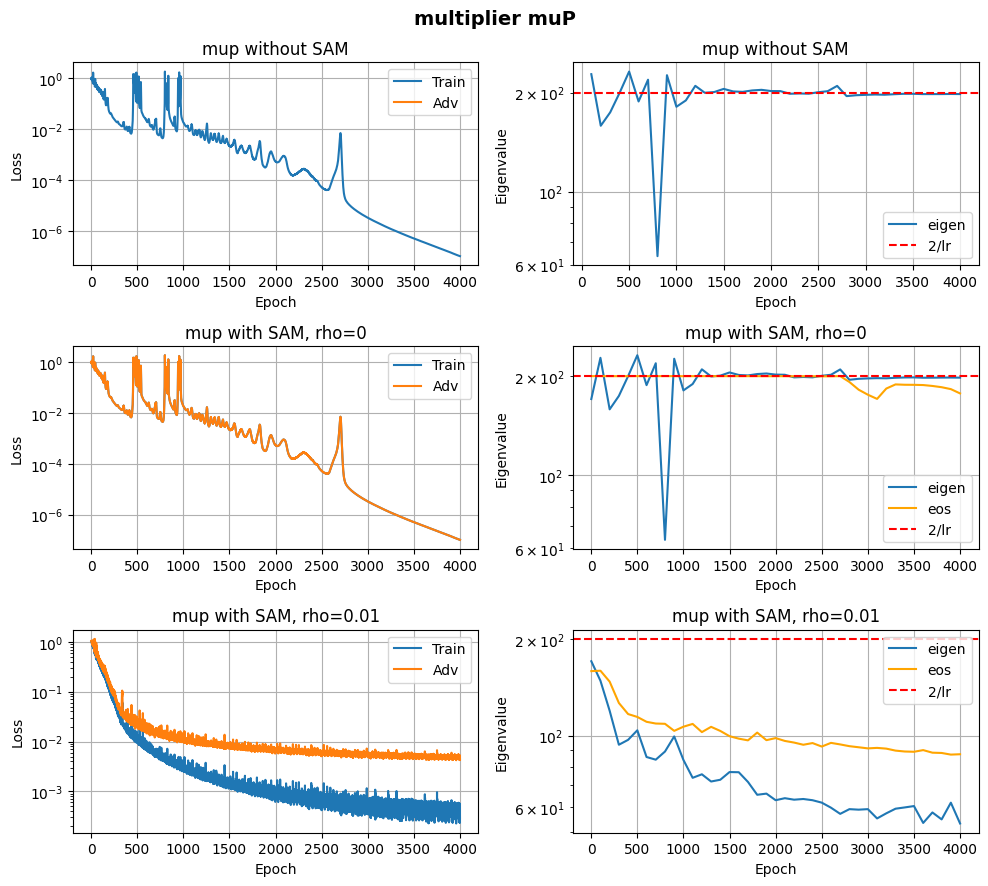

In [32]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(10, 9))

df_mup[["train", "adv"]].plot(ax=axes[0, 0], title="mup without SAM")
df_mup_rho0[["train", "adv"]].plot(ax=axes[1, 0], title="mup with SAM, rho=0")
df_mup_rho[["train", "adv"]].plot(ax=axes[2, 0], title=f"mup with SAM, rho={rho}")

df_mup[["eigen"]].dropna().plot(ax=axes[0, 1], title="mup without SAM")
df_mup_rho0[["eigen"]].dropna().plot(ax=axes[1, 1], title="mup with SAM, rho=0")
df_mup_rho[["eigen"]].dropna().plot(ax=axes[2, 1], title=f"mup with SAM, rho={rho}")

# df_mup[["eos"]].dropna().plot(ax=axes[0, 1], color="orange")
df_mup_rho0[["eos"]].dropna().plot(ax=axes[1, 1], color="orange", label="SAM-EOS")
df_mup_rho[["eos"]].dropna().plot(ax=axes[2, 1], color="orange", label="SAM-EOS")

axes[0, 1].axhline(2/lr, color="red", linestyle="--", label="2/lr")
axes[1, 1].axhline(2/lr, color="red", linestyle="--", label="2/lr")
axes[2, 1].axhline(2/lr, color="red", linestyle="--", label="2/lr")

for i in range(3):
    axes[i, 0].set_ylabel("Loss")
    axes[i, 0].set_xlabel("Epoch")
    axes[i, 1].set_ylabel("Eigenvalue")
    axes[i, 1].set_xlabel("Epoch")
    axes[i, 0].legend(["Train", "Adv"])
    axes[i, 1].legend()
    axes[i, 1].grid()
    axes[i, 0].grid()
    axes[i, 0].set_yscale("log")
    axes[i, 1].set_yscale("log")

plt.suptitle("multiplier muP", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## Hessian eval but multiplier free

In [21]:
# from pyhessian import hessian
from reparamhessian import ReparamHessian as hessian

torch.manual_seed(0)
np.random.seed(0)

# ---------- Plain muP training loop ----------
epochs = 4000
lr = 0.01
device = "cuda" if torch.cuda.is_available() else "cpu"
dl = get_cifar_toy(device=device)
sharp_x, sharp_y = next(iter(dl))
# model = MLP(num_classes=1).to(device)
model = muMLPTab9(num_classes=1, multiplier=False).to(device)
                             

optimiser = torch.optim.SGD(model.get_parameter_groups(lr, "SGD"), lr=lr, momentum=0, weight_decay=0)
loss_fn = nn.MSELoss()

df_mup = pd.DataFrame(columns=["train", "adv", "batch_size", "eigen"])
print("Epoch\tTrain\tAdv\tBatch Size")
for epoch in range(1, epochs + 1):
    losses_train, losses_adv, batch_sizes, g_norm = train_epoch(model, dl, optimiser, loss_fn, device)
    df_mup.loc[epoch] = [losses_train[0], losses_adv[0], batch_sizes[0], None]
    if epoch % 100 == 0 or epoch == 1:
        hess = hessian(model, criterion=loss_fn, data=(sharp_x, sharp_y), cuda=True, base_lr=lr, layer_lrs=model.layer_lrs)
        top_eigenvalue = hess.eigenvalues(maxIter=400, top_n=1)[0][0]
        df_mup.loc[epoch, "eigen"] = top_eigenvalue
        print(epoch, losses_train[0], losses_adv[0], batch_sizes[0], top_eigenvalue)

Epoch	Train	Adv	Batch Size
1 1.0064471002130584 None 50 170.3575406651261
100 0.3388710248971906 None 50 227.42149609513802
200 0.045536536985719474 None 50 158.4904701868277
300 0.01660463704028527 None 50 174.17944199801562
400 0.008510411422001997 None 50 199.92452875449857
500 0.10904112972316952 None 50 231.63701803608438
600 0.02192463448204492 None 50 187.8703145218621
700 0.02342238575543503 None 50 218.92709806271608
800 1.8720624708555835 None 50 63.62435848206313
900 0.018428449220176973 None 50 225.79250043720648
1000 0.018566283086371337 None 50 181.14036568778496
1100 0.008501753826697241 None 50 189.27390847088122
1200 0.0072939202400545515 None 50 209.74884486921027
1300 0.0067278339858356144 None 50 199.64171501154715
1400 0.002957280530744758 None 50 200.6663836986154
1500 0.0022886236938284765 None 50 205.2149936470767
1600 0.0015083873636789614 None 50 201.62369937094
1700 0.0016190095204189716 None 50 200.89869733428677
1800 0.0012019946973855023 None 50 202.926291

In [22]:
# ---------- SAM (rho=0) training loop ----------
torch.manual_seed(0)
np.random.seed(0)

rho = 0.0
model = muMLPTab9(num_classes=1).to(device)
base_opt = torch.optim.SGD
optimiser = SAM(model.get_parameter_groups(lr, "SGD"),
                base_opt,
                lr=lr, momentum=0, weight_decay=0,
                rho=rho)      

df_mup_rho0 = pd.DataFrame(columns=["train", "adv", "batch_size", "eigen", "eos"])
print("Epoch\tTrain\tAdv\tBatch Size")
for epoch in range(1, epochs + 1):
    losses_train, losses_adv, batch_sizes, g_norm = train_epoch(model, dl, optimiser, loss_fn, device)
    df_mup_rho0.loc[epoch] = [losses_train[0], losses_adv[0], batch_sizes[0], None, None]
    if epoch % 100 == 0 or epoch == 1:
        hess = hessian(model, criterion=loss_fn, data=(sharp_x, sharp_y), cuda=True, base_lr=lr, layer_lrs=model.layer_lrs)
        top_eigenvalue = hess.eigenvalues(maxIter=400, top_n=1)[0][0]
        sam_edge = (g_norm / (2*0.000001)) * ( (1 + 8*0.000001/(lr*g_norm)).sqrt() - 1 )
        df_mup_rho0.loc[epoch, "eigen"] = top_eigenvalue
        df_mup_rho0.loc[epoch, "eos"] = sam_edge.item()
        print(epoch, top_eigenvalue, sam_edge)

# ---------- SAM (rho!=0) training loop ----------
torch.manual_seed(0)
np.random.seed(0)

rho = 0.01
model = muMLPTab9(num_classes=1).to(device)
base_opt = torch.optim.SGD
optimiser = SAM(model.get_parameter_groups(lr, "SGD"),
                base_opt,
                lr=lr, momentum=0, weight_decay=0,
                rho=rho)      

df_mup_rho = pd.DataFrame(columns=["train", "adv", "batch_size", "eigen", "eos"])
print("Epoch\tTrain\tAdv\tBatch Size")
for epoch in range(1, epochs + 1):
    losses_train, losses_adv, batch_sizes, g_norm = train_epoch(model, dl, optimiser, loss_fn, device)
    df_mup_rho.loc[epoch] = [losses_train[0], losses_adv[0], batch_sizes[0], None, None]
    if epoch % 100 == 0 or epoch == 1:
        hess = hessian(model, criterion=loss_fn, data=(sharp_x, sharp_y), cuda=True, base_lr=lr, layer_lrs=model.layer_lrs)
        top_eigenvalue = hess.eigenvalues(maxIter=400, top_n=1)[0][0]
        sam_edge = (g_norm / (2*rho)) * ( (1 + 8*rho/(lr*g_norm)).sqrt() - 1 )
        df_mup_rho.loc[epoch, "eigen"] = top_eigenvalue
        df_mup_rho.loc[epoch, "eos"] = sam_edge.item()
        print(epoch, top_eigenvalue, sam_edge.item())

Epoch	Train	Adv	Batch Size
1 170.3575406651262 tensor(199.9910, device='cuda:0')
100 227.42149609513817 tensor(199.9944, device='cuda:0')
200 158.49047018682776 tensor(199.9325, device='cuda:0')
300 174.17944199801553 tensor(199.9309, device='cuda:0')
400 199.9245287544987 tensor(199.9194, device='cuda:0')
500 231.6370180360839 tensor(199.9818, device='cuda:0')
600 187.87031452186181 tensor(199.9567, device='cuda:0')
700 218.92709806271588 tensor(199.9849, device='cuda:0')
800 63.624358482065574 tensor(199.9986, device='cuda:0')
900 225.79250043719068 tensor(199.9755, device='cuda:0')
1000 181.14036568759093 tensor(199.9075, device='cuda:0')
1100 189.27390847083257 tensor(199.9569, device='cuda:0')
1200 209.74884486910702 tensor(199.9681, device='cuda:0')
1300 199.64171501146916 tensor(199.9697, device='cuda:0')
1400 200.66638369855676 tensor(199.9484, device='cuda:0')
1500 205.21499364699773 tensor(199.9453, device='cuda:0')
1600 201.62369937086822 tensor(199.9340, device='cuda:0')
17

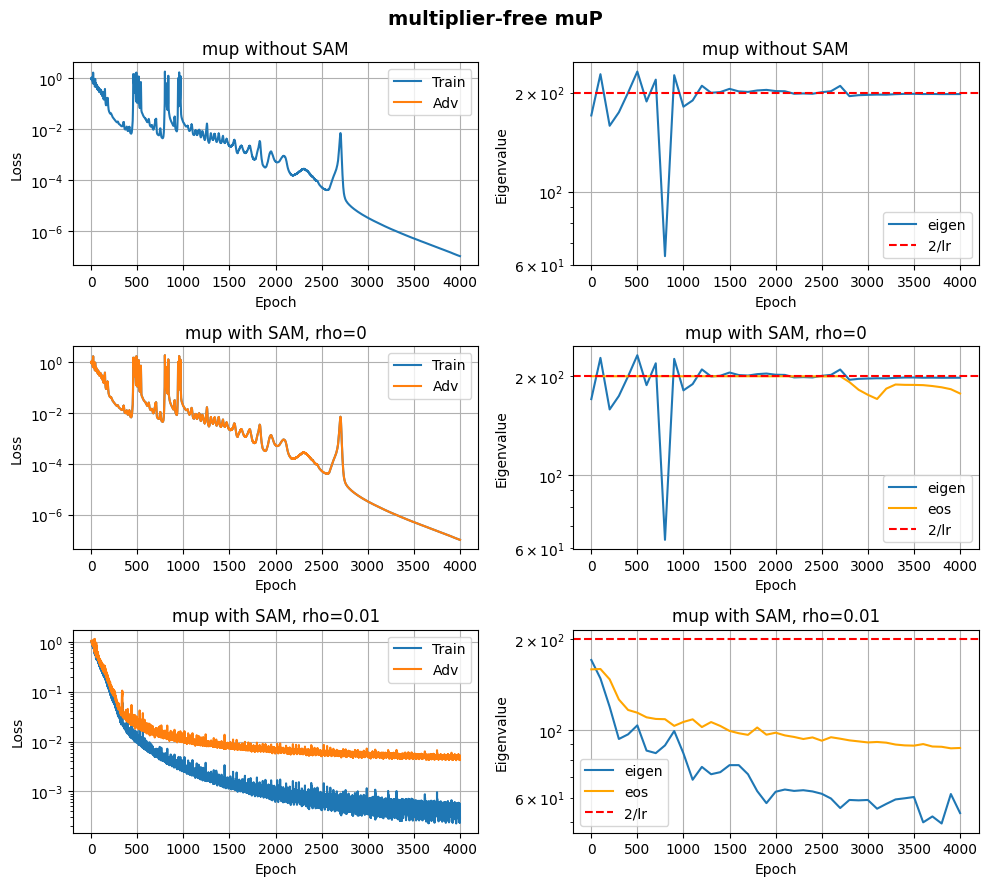

In [28]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(10, 9))

df_mup[["train", "adv"]].plot(ax=axes[0, 0], title="mup without SAM")
df_mup_rho0[["train", "adv"]].plot(ax=axes[1, 0], title="mup with SAM, rho=0")
df_mup_rho[["train", "adv"]].plot(ax=axes[2, 0], title=f"mup with SAM, rho={rho}")

df_mup[["eigen"]].dropna().plot(ax=axes[0, 1], title="mup without SAM")
df_mup_rho0[["eigen"]].dropna().plot(ax=axes[1, 1], title="mup with SAM, rho=0")
df_mup_rho[["eigen"]].dropna().plot(ax=axes[2, 1], title=f"mup with SAM, rho={rho}")

# df_mup[["eos"]].dropna().plot(ax=axes[0, 1], color="orange")
df_mup_rho0[["eos"]].dropna().plot(ax=axes[1, 1], color="orange", label="SAM-EOS")
df_mup_rho[["eos"]].dropna().plot(ax=axes[2, 1], color="orange", label="SAM-EOS")

axes[0, 1].axhline(2/lr, color="red", linestyle="--", label="2/lr")
axes[1, 1].axhline(2/lr, color="red", linestyle="--", label="2/lr")
axes[2, 1].axhline(2/lr, color="red", linestyle="--", label="2/lr")

for i in range(3):
    axes[i, 0].set_ylabel("Loss")
    axes[i, 0].set_xlabel("Epoch")
    axes[i, 1].set_ylabel("Eigenvalue")
    axes[i, 1].set_xlabel("Epoch")
    axes[i, 0].legend(["Train", "Adv"])
    axes[i, 1].legend()
    axes[i, 1].grid()
    axes[i, 0].grid()
    axes[i, 0].set_yscale("log")
    axes[i, 1].set_yscale("log")

plt.suptitle("multiplier-free muP", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()